# Mestrado em Inteligência Artificial 25/26
# Practical 8 — Policy Gradient: REINFORCE on TicTacToe

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from envs.tictactoe import TicTacToeEnv
from features.tictactoe import encode_state, STATE_FEATURE_DIM
from agents.control.reinforce import ReinforceAgent
from experiments.reinforce_tictactoe import (
    train,
    make_reinforce_policy,
    evaluate_vs_random,
    _play_silent,
)
from experiments.tictactoe import play_game, play_game_vs_human
from policies.tictactoe import random_action

---
## 1. Recap — the 27-dimensional feature vector

Each board state is encoded **from the current player's perspective**:

| Cell content | Encoding |
|---|---|
| My piece     | `[1, 0, 0]` |
| Opponent     | `[0, 1, 0]` |
| Empty        | `[0, 0, 1]` |

9 cells × 3 dims = **27 features** (`STATE_FEATURE_DIM = 27`).

Because the encoding is perspective-relative, **the same policy weights work for both X and O**,
which is exactly what we exploit in self-play.

Let's visualise the encoding for a concrete board.

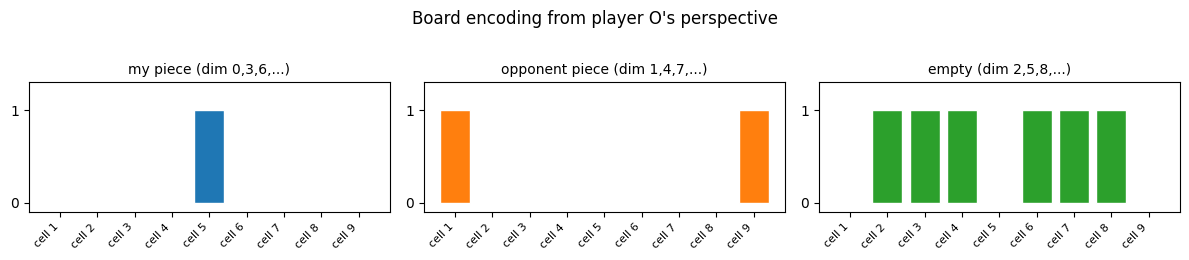

Board:
X . .

. O .

. . X

Feature vector (27 dims): [0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.
 0. 1. 0.]


In [2]:
# Example board after three moves
#   X | 2 | 3
#   4 | O | 6
#   7 | 8 | X
sample_board = (1, 0, 0, 0, -1, 0, 0, 0, 1)
current_player = -1  # O's turn

phi = encode_state(sample_board, current_player)

fig, axes = plt.subplots(1, 3, figsize=(12, 2.5))
titles = ["my piece (dim 0,3,6,...)", "opponent piece (dim 1,4,7,...)", "empty (dim 2,5,8,...)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

for k, (ax, title, color) in enumerate(zip(axes, titles, colors)):
    vals = phi[k::3]   # every 3rd element starting at k
    ax.bar(range(9), vals, color=color, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(9))
    ax.set_xticklabels([f"cell {i+1}" for i in range(9)], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(-0.1, 1.3)
    ax.set_yticks([0, 1])

fig.suptitle(f"Board encoding from player {'O' if current_player == -1 else 'X'}'s perspective", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

env = TicTacToeEnv()
env.board = sample_board
print("Board:")
env.render(sample_board)
print(f"\nFeature vector (27 dims): {phi}")

---
## 2. REINFORCE algorithm

**Linear softmax policy** ($\theta \in \mathbb{R}^{9 \times 27}$):

**Self-play**: X and O share the same $\theta$. Trajectories are collected separately; the winner gets $r=+1$, the loser $r=-1$, all intermediate steps $r=0$.

---
## 3. Training

In [3]:
SEED               = 42
NUM_EPISODES       = 100_000
ALPHA              = 0.02
GAMMA              = 1.0
ENTROPY_BETA       = 0.01
RANDOM_OPP_FRAC    = 0.5   # fraction of episodes vs random opponent (rest = self-play)
EVAL_EVERY         = 2_000
EVAL_GAMES         = 500

env   = TicTacToeEnv()
agent = ReinforceAgent(alpha=ALPHA, gamma=GAMMA, entropy_beta=ENTROPY_BETA, seed=SEED)
results = train(
    agent,
    num_episodes=NUM_EPISODES,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_GAMES,
    random_opp_fraction=RANDOM_OPP_FRAC,
)

print(f"Win rate as X: {results['win_rates_as_x'][-1]:.1%}")
print(f"Win rate as O: {results['win_rates_as_o'][-1]:.1%}")

Win rate as X: 95.6%
Win rate as O: 77.4%


---
## 4. Learning curves

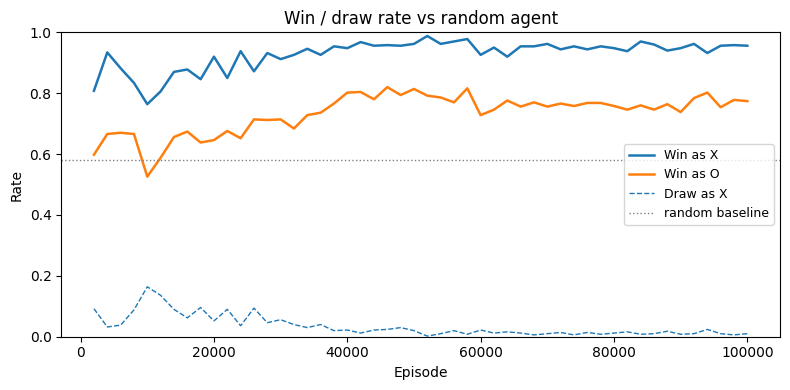

In [4]:
checkpoints = results["eval_checkpoints"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(checkpoints, results["win_rates_as_x"],  label="Win as X", color="tab:blue",   linewidth=1.8)
ax.plot(checkpoints, results["win_rates_as_o"],  label="Win as O", color="tab:orange",  linewidth=1.8)
ax.plot(checkpoints, results["draw_rates_as_x"], label="Draw as X", color="tab:blue",  linewidth=1, linestyle="--")
ax.axhline(0.58, color="grey", linestyle=":", linewidth=1, label="random baseline")
ax.set_xlabel("Episode"); ax.set_ylabel("Rate")
ax.set_title("Win / draw rate vs random agent")
ax.legend(fontsize=9); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## 5. Watching two trained agents play

Both X and O use the **greedy** policy extracted from the trained agent.

In [5]:
reinforce_policy = make_reinforce_policy(agent, greedy=True)

print("=" * 40)
print(" REINFORCE (X)  vs  REINFORCE (O)")
print("=" * 40)
result = play_game(env, reinforce_policy, reinforce_policy, render=True)

 REINFORCE (X)  vs  REINFORCE (O)
Initial board:
. . .

. . .

. . .

Player X plays cell 5:
. . .

. X .

. . .

Player O plays cell 1:
O . .

. X .

. . .

Player X plays cell 7:
O . .

. X .

X . .

Player O plays cell 6:
O . .

. X O

X . .

Player X plays cell 3:
O . X

. X O

X . .

X wins!


In [6]:
n = 1_000
outcomes = {1: 0, -1: 0, 0: 0}
for _ in range(n):
    outcomes[_play_silent(env, reinforce_policy, reinforce_policy)] += 1

print(f"Over {n} self-play games:")
print(f"  X wins: {outcomes[1]/n:.1%}  |  O wins: {outcomes[-1]/n:.1%}  |  Draws: {outcomes[0]/n:.1%}")

Over 1000 self-play games:
  X wins: 100.0%  |  O wins: 0.0%  |  Draws: 0.0%


---
## 6. Play against the trained agent

```
 1 | 2 | 3
-----------
 4 | 5 | 6
-----------
 7 | 8 | 9
```

`human_plays=-1` → you play as O (second).  Change to `1` to play as X.

In [7]:
play_game_vs_human(env, reinforce_policy, human_plays=-1)

Initial board:
. . .

. . .

. . .

Player X plays cell 5:
. . .

. X .

. . .

Player O plays cell 1:
O . .

. X .

. . .

Player X plays cell 7:
O . .

. X .

X . .

Player O plays cell 3:
O . O

. X .

X . .

Player X plays cell 4:
O . O

X X .

X . .

Player O plays cell 2:
O O O

X X .

X . .

O wins!


-1